# 04 — Análisis exploratorio del histórico

**Proyecto:** RepostaPro — Optimización del repostaje en flotas comerciales  
**Autor:** Víctor González Martín  
**Notebook:** 04 — EDA temporal del dataset histórico consolidado 

## Objetivo del notebook

Caracterizar la dimensión temporal del dataset histórico construido en el notebook 2 (período 1 enero 2024 — 14 junio 2026). El análisis inicial se realizó sobre un único *snapshot*, lo que limitaba la visión a un momento concreto del mercado. Con el histórico de 895 días disponible, podemos extraer hallazgos hasta ahora inaccesibles:

- Evolución del precio medio nacional por carburante.
- Confirmación o refutación de la **inversión histórica diésel/gasolina**.
- Detección de eventos puntuales relevantes (crisis geopolíticas, reformas fiscales).
- Caracterización de la estacionalidad (semanal, mensual, anual).
- Calidad de la serie temporal: huecos, anomalías, outliers geográficos.

Los hallazgos de este notebook orientarán las decisiones de **feature engineering** y de **modelado predictivo**.

In [2]:
# Configuración del entorno
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual de los gráficos: profesional, sobrio
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.family"] = "Calibri"
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

# Suprimir warnings de pandas que ensucian la salida
warnings.filterwarnings("ignore", category=FutureWarning)

# Rutas del proyecto
CARPETA_PROCESSED = Path("../data/processed")
CARPETA_FIGURAS = Path("../outputs/figures")
CARPETA_FIGURAS.mkdir(parents=True, exist_ok=True)

print(f"Carpeta de datos:    {CARPETA_PROCESSED.resolve()}")
print(f"Carpeta de figuras:  {CARPETA_FIGURAS.resolve()}")

Carpeta de datos:    C:\TFM\data\processed
Carpeta de figuras:  C:\TFM\outputs\figures


## Carga del histórico completo

Cargamos los 3 Parquet anuales generados y los unimos en un único DataFrame de aproximadamente 10 millones de filas. Es la primera vez en el proyecto que trabajamos con el histórico completo.

In [3]:
# Cargar y concatenar los 3 Parquet anuales
ficheros_parquet = sorted(CARPETA_PROCESSED.glob("historico_carburantes_*.parquet"))
print(f"Ficheros Parquet a cargar: {len(ficheros_parquet)}")
for f in ficheros_parquet:
    print(f"  - {f.name} ({f.stat().st_size / 1024 / 1024:.1f} MB)")

# Carga + concatenación
print("\nCargando...")
df = pd.concat([pd.read_parquet(f) for f in ficheros_parquet],ignore_index=True,)

print(f"\nDataset cargado")
print(f"  Filas:    {len(df):,}")
print(f"  Columnas: {df.shape[1]}")
print(f"  Memoria:  {df.memory_usage(deep=True).sum() / 1024 / 1024 / 1024:.2f} GB")
print(f"  Rango temporal: {df['fecha'].min().date()} → {df['fecha'].max().date()}")
print(f"  Días únicos:    {df['fecha'].nunique():,}")
print(f"  Estaciones únicas (total histórico): {df['IDEESS'].nunique():,}")

Ficheros Parquet a cargar: 3
  - historico_carburantes_2024.parquet (75.5 MB)
  - historico_carburantes_2025.parquet (76.3 MB)
  - historico_carburantes_2026.parquet (35.1 MB)

Cargando...

Dataset cargado
  Filas:    10,040,121
  Columnas: 25
  Memoria:  2.95 GB
  Rango temporal: 2024-01-01 → 2026-06-14
  Días únicos:    893
  Estaciones únicas (total histórico): 11,917


## Caracterización temporal: huecos y cobertura

Antes de analizar la evolución de precios, validamos la **calidad de la serie temporal**. Verificamos:

- Que tenemos un registro para cada día del rango (sin huecos).
- Cuántas estaciones declaran precio cada día (cobertura diaria).
- Variabilidad del número de estaciones a lo largo del tiempo.

In [4]:
# Estaciones por día
estaciones_por_dia = df.groupby("fecha")["IDEESS"].nunique().sort_index()

print(f"Días con datos en el histórico:     {len(estaciones_por_dia):,}")
print(f"Días esperados (rango completo):    {(df['fecha'].max() - df['fecha'].min()).days + 1:,}")

# Días sin datos
fechas_esperadas = pd.date_range(df["fecha"].min(), df["fecha"].max(), freq="D")
fechas_presentes = set(df["fecha"].unique())
fechas_faltantes = [f for f in fechas_esperadas if f not in fechas_presentes]
print(f"Días faltantes:                     {len(fechas_faltantes):,}")
if fechas_faltantes:
    print(f"  Primeros faltantes: {[str(f.date()) for f in fechas_faltantes[:5]]}")

print(f"\nEstaciones declaradas por día:")
print(f"  Mínimo:   {estaciones_por_dia.min():,}")
print(f"  Máximo:   {estaciones_por_dia.max():,}")
print(f"  Media:    {estaciones_por_dia.mean():,.0f}")
print(f"  Mediana:  {estaciones_por_dia.median():,.0f}")
print(f"  Desv.tip: {estaciones_por_dia.std():.0f}")

Días con datos en el histórico:     893
Días esperados (rango completo):    896
Días faltantes:                     3
  Primeros faltantes: ['2024-12-14', '2025-05-21', '2025-05-22']

Estaciones declaradas por día:
  Mínimo:   10,940
  Máximo:   11,529
  Media:    11,243
  Mediana:  11,226
  Desv.tip: 106


## Visualización de la cobertura diaria

Graficamos la evolución del número de estaciones declarantes a lo largo del tiempo. Picos abruptos o caídas pronunciadas indicarían problemas en la API o cambios en la metodología de publicación.

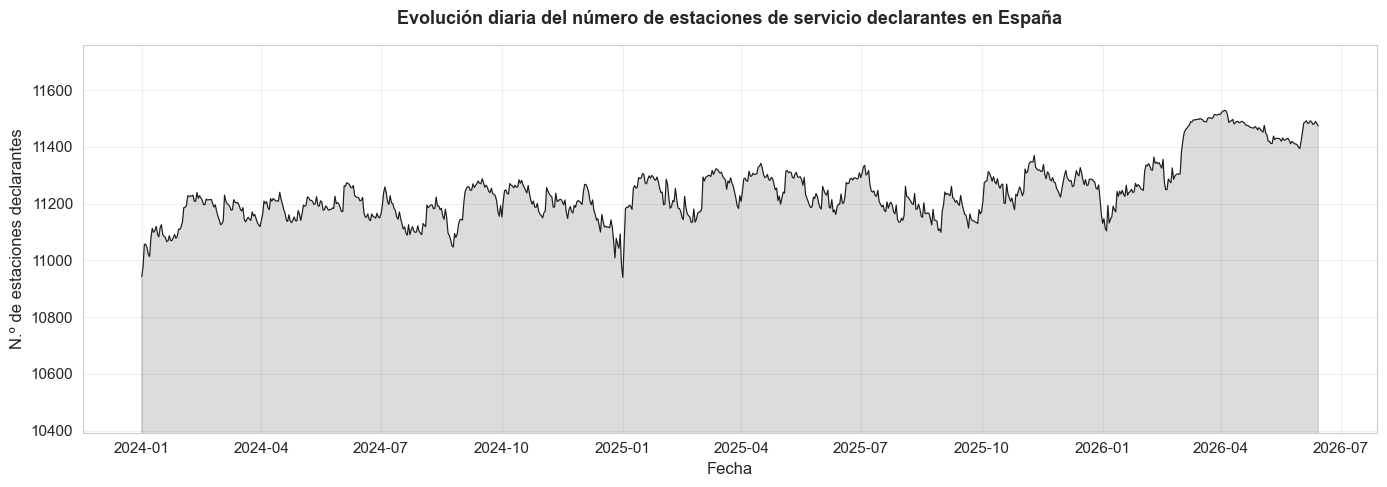


Figura guardada en: ..\outputs\figures\cobertura_diaria_estaciones.png


In [5]:
# Cobertura diaria
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(estaciones_por_dia.index, estaciones_por_dia.values, color="#1A1A1A", linewidth=0.8)
ax.fill_between(estaciones_por_dia.index, estaciones_por_dia.values, alpha=0.15, color="#1A1A1A")

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("N.º de estaciones declarantes", fontsize=12)
ax.set_title("Evolución diaria del número de estaciones de servicio declarantes en España",fontsize=13, fontweight="bold", pad=15)
ax.grid(True, alpha=0.3)
ax.set_ylim(estaciones_por_dia.min() * 0.95, estaciones_por_dia.max() * 1.02)

plt.tight_layout()
ruta_fig = CARPETA_FIGURAS / "cobertura_diaria_estaciones.png"
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()

print(f"\nFigura guardada en: {ruta_fig}")

## Construcción del dataset diario

Para analizar la evolución temporal del mercado, agregamos los datos por día y carburante. El resultado (`df_diario`) es un dataset compacto con el precio medio nacional de cada carburante para cada día del histórico.

Este dataset será la **entrada principal** del modelado predictivo posterior.

In [7]:
# Construcción del dataset diario: precio medio nacional por carburante
columnas_precio = [
    "Precio Gasoleo A",
    "Precio Gasoleo Premium",
    "Precio Gasolina 95 E5",
    "Precio Gasolina 98 E5",
    "Precio Gases licuados del petróleo",
    "Precio Adblue",]

df_diario = df.groupby("fecha")[columnas_precio].mean().round(4)

print(f"Dataset diario construido:")
print(f"  Filas:    {len(df_diario):,}")
print(f"  Columnas: {df_diario.shape[1]}")
print(f"  Rango:    {df_diario.index.min().date()} → {df_diario.index.max().date()}\n")

print("Estadísticas del precio medio diario por carburante:")
print(df_diario.describe().round(3).T[["mean", "std", "min", "max"]])

Dataset diario construido:
  Filas:    893
  Columnas: 6
  Rango:    2024-01-01 → 2026-06-14

Estadísticas del precio medio diario por carburante:
                                     mean    std    min    max
Precio Gasoleo A                    1.476  0.112  1.356  1.942
Precio Gasoleo Premium              1.576  0.108  1.454  2.018
Precio Gasolina 95 E5               1.529  0.068  1.431  1.796
Precio Gasolina 98 E5               1.694  0.064  1.604  1.930
Precio Gases licuados del petróleo  0.946  0.023  0.914  1.028
Precio Adblue                       0.859  0.036  0.828  0.940


## Evolución temporal del precio medio: los cuatro carburantes principales

Graficamos la evolución diaria del precio medio nacional de los cuatro carburantes del núcleo predictivo (Gasóleo A, Gasolina 95 E5, Gasóleo Premium, Gasolina 98 E5).

**Hipótesis a verificar**: la inversión histórica diésel/gasolina detectada en el snapshot del 6 de junio de 2026, ¿se produce realmente a lo largo del período 2024-2026 o es un fenómeno puntual?

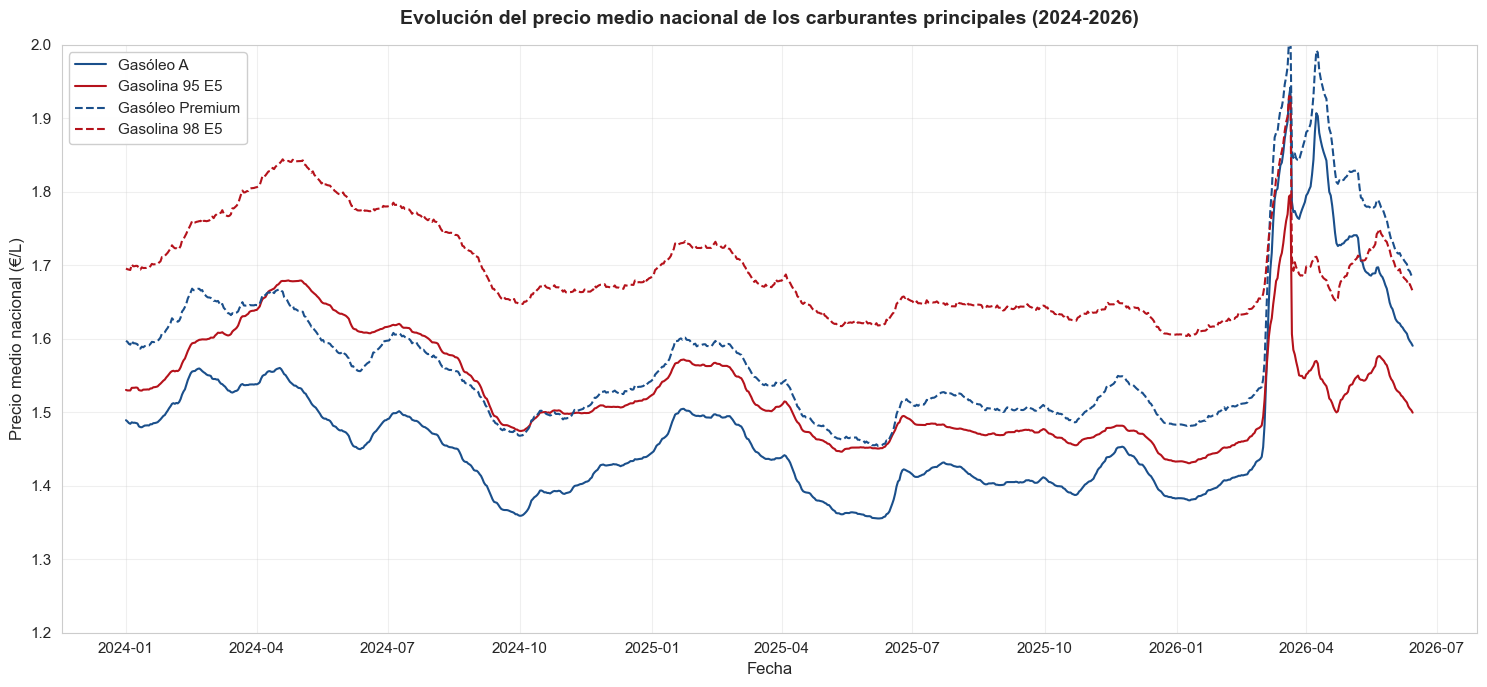


 Figura guardada en: ..\outputs\figures\evolucion_precios_4_carburantes.png


In [8]:
# Evolución temporal del precio medio 
fig, ax = plt.subplots(figsize=(15, 7))

# Definimos colores y estilos
config_carburantes = {
    "Precio Gasoleo A":         {"color": "#1A4F8B", "linestyle": "-",  "label": "Gasóleo A"},
    "Precio Gasolina 95 E5":    {"color": "#B5121B", "linestyle": "-",  "label": "Gasolina 95 E5"},
    "Precio Gasoleo Premium":   {"color": "#1A4F8B", "linestyle": "--", "label": "Gasóleo Premium"},
    "Precio Gasolina 98 E5":    {"color": "#B5121B", "linestyle": "--", "label": "Gasolina 98 E5"},}

for col, cfg in config_carburantes.items():
    ax.plot(df_diario.index, df_diario[col],color=cfg["color"], linestyle=cfg["linestyle"],linewidth=1.5, label=cfg["label"])

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Precio medio nacional (€/L)", fontsize=12)
ax.set_title("Evolución del precio medio nacional de los carburantes principales (2024-2026)",fontsize=14, fontweight="bold", pad=15)
ax.legend(loc="upper left", fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_ylim(1.2, 2.0)

plt.tight_layout()
ruta_fig = CARPETA_FIGURAS / "evolucion_precios_4_carburantes.png"
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()

print(f"\n Figura guardada en: {ruta_fig}")

## Confirmación de la inversión diésel/gasolina

Calculamos el diferencial diario entre el precio del Gasóleo A y el precio de la Gasolina 95 E5:

- **Diferencial positivo** = Gasolina más cara que Gasóleo (situación histórica).
- **Diferencial negativo** = Gasóleo más caro que Gasolina (situación reciente).

Identificamos visual y numéricamente en qué fecha cambia la jerarquía.

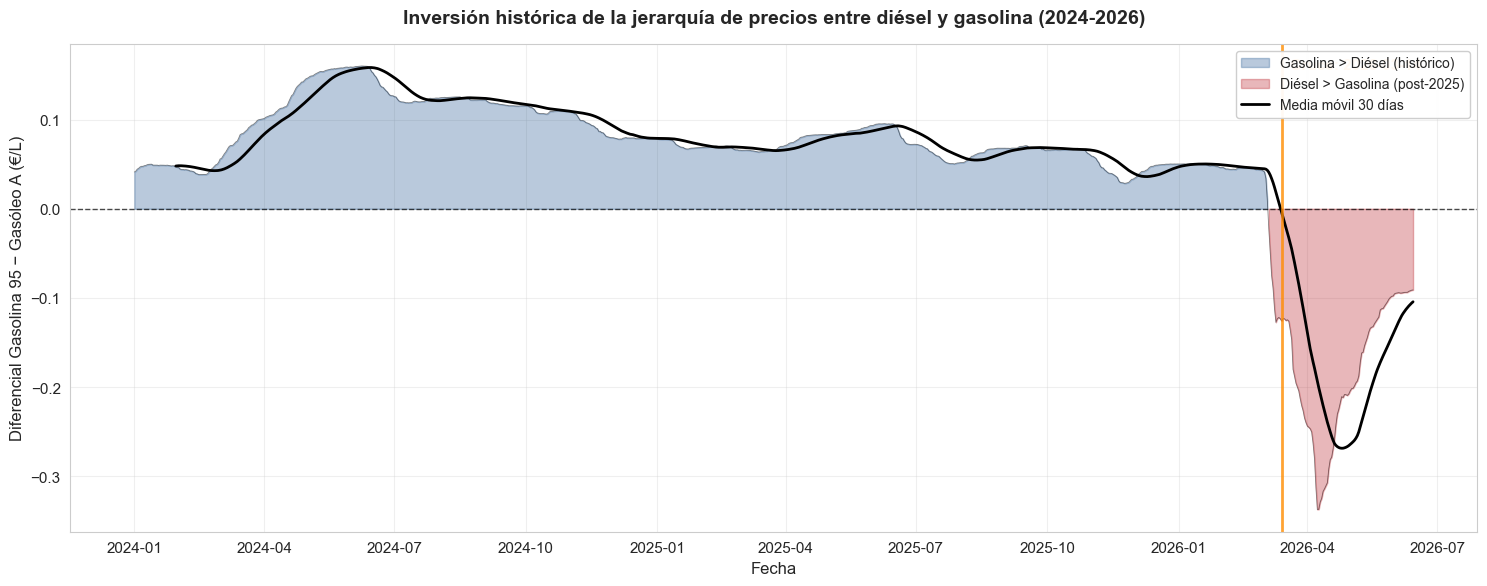


✓ Figura guardada en: ..\outputs\figures\inversion_diesel_gasolina.png

>>> FECHA DE CRUCE: 2026-03-14
    Día de la semana: Saturday
    Mes: March 2026


In [9]:
# Diferencial Gasolina 95 - Gasóleo A
df_diario["diferencial_95_gasoleo"] = (df_diario["Precio Gasolina 95 E5"] - df_diario["Precio Gasoleo A"])

# Identificar fecha de cambio: primer día donde el diferencial pasa de positivo a negativo
df_diario["diferencial_mm30"] = df_diario["diferencial_95_gasoleo"].rolling(window=30).mean()

# Buscamos el primer día donde la media móvil cruza el cero hacia negativo
cruce = None
for i in range(30, len(df_diario)):
    if df_diario["diferencial_mm30"].iloc[i] < 0 and df_diario["diferencial_mm30"].iloc[i-1] >= 0:
        cruce = df_diario.index[i]
        break

# Gráfico del diferencial
fig, ax = plt.subplots(figsize=(15, 6))

ax.fill_between(df_diario.index, df_diario["diferencial_95_gasoleo"], 0,where=df_diario["diferencial_95_gasoleo"] >= 0,color="#1A4F8B", alpha=0.3, label="Gasolina > Diésel (histórico)")
ax.fill_between(df_diario.index, df_diario["diferencial_95_gasoleo"], 0,where=df_diario["diferencial_95_gasoleo"] < 0,color="#B5121B", alpha=0.3, label="Diésel > Gasolina (post-2025)")

ax.plot(df_diario.index, df_diario["diferencial_95_gasoleo"],color="#1A1A1A", linewidth=0.6, alpha=0.5)
ax.plot(df_diario.index, df_diario["diferencial_mm30"],color="#000000", linewidth=2, label="Media móvil 30 días")
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)

if cruce:
    ax.axvline(cruce, color="#FF8C00", linewidth=2, linestyle="-", alpha=0.8)
    ax.text(cruce, ax.get_ylim()[1] * 0.85, f"  Cruce: {cruce.date()}",
            color="#FF8C00", fontsize=11, fontweight="bold")

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Diferencial Gasolina 95 − Gasóleo A (€/L)", fontsize=12)
ax.set_title("Inversión histórica de la jerarquía de precios entre diésel y gasolina (2024-2026)",fontsize=14, fontweight="bold", pad=15)
ax.legend(loc="upper right", fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
ruta_fig = CARPETA_FIGURAS / "inversion_diesel_gasolina.png"
plt.savefig(ruta_fig, dpi=200, bbox_inches="tight")
plt.show()

print(f"\n✓ Figura guardada en: {ruta_fig}")
if cruce:
    print(f"\n>>> FECHA DE CRUCE: {cruce.date()}")
    print(f"    Día de la semana: {cruce.strftime('%A')}")
    print(f"    Mes: {cruce.strftime('%B %Y')}")

## Análisis de los outliers geográficos en el histórico

Se detectaron 712 outliers geográficos durante la consolidación del año 2024 (estaciones con coordenadas fuera del bounding box de España). Sin embargo, sobre el snapshot del 6 de junio de 2026, solo se detectaron 3 outliers. Esta diferencia llama la atención y merece investigación.

**Hipótesis 1**: los 712 outliers corresponden a 3 estaciones que tienen coordenadas inconsistentes en muchos días (3 estaciones × ~240 días ≈ 720). Esto significaría que el problema es siempre el mismo, no errores puntuales.

**Hipótesis 2**: las coordenadas inconsistentes varían por días: ciertos días el Ministerio publica las coordenadas mal para muchas estaciones distintas.

In [10]:
# Investigación de los outliers geográficos
df_outliers = df[df["outlier_geografico"] == True]

print(f"Total de filas marcadas como outlier en el histórico: {len(df_outliers):,}")
print(f"Estaciones únicas afectadas:     {df_outliers['IDEESS'].nunique():,}")
print(f"Días afectados:                  {df_outliers['fecha'].nunique():,}")

print("\nTOP 10 estaciones con más días como outlier:")
print(df_outliers.groupby(["IDEESS", "Rótulo"]).size()
      .sort_values(ascending=False).head(10).to_string())

print("\nDistribución de outliers por año:")
print(df_outliers.groupby(df_outliers["fecha"].dt.year).size().to_string())

Total de filas marcadas como outlier en el histórico: 1,945
Estaciones únicas afectadas:     3
Días afectados:                  893

TOP 10 estaciones con más días como outlier:
IDEESS  Rótulo      
12883   SUPER GASOIL    823
11988   PETROZAL        726
16268   GUAY            396

Distribución de outliers por año:
fecha
2024    712
2025    786
2026    447


## Caracterización cuantitativa del shock de marzo 2026

Comparamos el comportamiento del mercado en cuatro ventanas temporales para cuantificar el impacto:

- **Ventana 1 (pre-shock estable)**: enero 2026.
- **Ventana 2 (pico del shock)**: del 14 al 25 de marzo de 2026.
- **Ventana 3 (post-medidas fiscales)**: del 22 de marzo al 28 de abril de 2026 (entrada del Real Decreto-ley 7/2026).
- **Ventana 4 (régimen actual)**: junio 2026.

Esta comparativa cuantifica el shock, valida la cronología publicada por la CNMC y respalda la decisión de modelado dual.

In [11]:
# Caracterización cuantitativa del shock por ventanas temporales
from datetime import date

ventanas = {
    "1. Pre-shock estable (ene 2026)":        (date(2026, 1, 1),  date(2026, 1, 31)),
    "2. Pico del shock (14-25 mar 2026)":     (date(2026, 3, 14), date(2026, 3, 25)),
    "3. Post-RD-ley (22 mar - 28 abr 2026)":  (date(2026, 3, 22), date(2026, 4, 28)),
    "4. Régimen actual (jun 2026)":           (date(2026, 6, 1),  date(2026, 6, 14)),}

print(f"{'Ventana':<45} {'Gasoleo A':>12} {'Gasolina 95':>14} {'Diferencial':>14}")
print("-" * 90)

for nombre, (inicio, fin) in ventanas.items():
    mascara = (df_diario.index.date >= inicio) & (df_diario.index.date <= fin)
    sub = df_diario[mascara]
    
    media_gasoleo = sub["Precio Gasoleo A"].mean()
    media_gasolina = sub["Precio Gasolina 95 E5"].mean()
    diferencial = media_gasolina - media_gasoleo
    
    print(f"{nombre:<45} {media_gasoleo:>10.3f} €/L "
          f"{media_gasolina:>12.3f} €/L {diferencial:>+10.3f} €/L")

print("\nMagnitud absoluta del shock (pico vs pre-shock):")
pre = df_diario[(df_diario.index.date >= date(2026, 1, 1)) & (df_diario.index.date <= date(2026, 1, 31))]
pico = df_diario[(df_diario.index.date >= date(2026, 3, 14)) & (df_diario.index.date <= date(2026, 3, 25))]

print(f"  Subida Gasoleo A:        {pico['Precio Gasoleo A'].mean() - pre['Precio Gasoleo A'].mean():+.3f} €/L "
      f"({(pico['Precio Gasoleo A'].mean() / pre['Precio Gasoleo A'].mean() - 1) * 100:+.1f}%)")
print(f"  Subida Gasolina 95:      {pico['Precio Gasolina 95 E5'].mean() - pre['Precio Gasolina 95 E5'].mean():+.3f} €/L "
      f"({(pico['Precio Gasolina 95 E5'].mean() / pre['Precio Gasolina 95 E5'].mean() - 1) * 100:+.1f}%)")

Ventana                                          Gasoleo A    Gasolina 95    Diferencial
------------------------------------------------------------------------------------------
1. Pre-shock estable (ene 2026)                    1.388 €/L        1.437 €/L     +0.049 €/L
2. Pico del shock (14-25 mar 2026)                 1.846 €/L        1.697 €/L     -0.149 €/L
3. Post-RD-ley (22 mar - 28 abr 2026)              1.797 €/L        1.543 €/L     -0.254 €/L
4. Régimen actual (jun 2026)                       1.612 €/L        1.519 €/L     -0.093 €/L

Magnitud absoluta del shock (pico vs pre-shock):
  Subida Gasoleo A:        +0.458 €/L (+33.0%)
  Subida Gasolina 95:      +0.260 €/L (+18.1%)


## Confirmación de la fecha de corte entre régimenes

La media móvil de 30 días cruza el cero el 14 de marzo de 2026, pero esto es un indicador suavizado. Para el modelado conviene definir una fecha de corte más precisa que separe los dos régimenes. Tenemos dos candidatos:

- **Opción 1**: 28 de febrero de 2026 → fecha del inicio del conflicto (ataques EEUU-Israel a Irán). Cronológicamente exacto.
- **Opción 2**: 14 de marzo de 2026 → fecha del cruce de jerarquía detectado en la serie. Estadísticamente significativo.

La decisión final tendrá en cuenta también la fecha del Real Decreto-ley 7/2026 (22 de marzo) que introduce una discontinuidad fiscal adicional.

In [17]:
# Análisis fino día a día alrededor del shock
ventana_shock = df_diario.loc["2026-02-15":"2026-04-15"].copy()

print("Evolución diaria alrededor del shock:")
print(f"{'Fecha':<12} {'Gasoleo A':>10} {'Gasolina 95':>12} {'Diferencial':>12}")
print("-" * 50)

ventana_shock_compacta = ventana_shock[["Precio Gasoleo A", "Precio Gasolina 95 E5"]].copy()
ventana_shock_compacta["diferencial"] = (ventana_shock_compacta["Precio Gasolina 95 E5"] 
                                          - ventana_shock_compacta["Precio Gasoleo A"])

# Mostramos solo cada 3 días para no saturar
for fecha, fila in ventana_shock_compacta.iloc[::3].iterrows():
    marcador = "  <--- CRUCE" if abs(fila['diferencial']) < 0.005 else ""
    print(f"{fecha.date()}    {fila['Precio Gasoleo A']:>7.3f}    "
          f"{fila['Precio Gasolina 95 E5']:>9.3f}    {fila['diferencial']:>+9.3f}{marcador}")

# Detección automática del cruce DÍA EXACTO
ventana_shock_compacta["signo"] = np.sign(ventana_shock_compacta["diferencial"])
cambios_signo = ventana_shock_compacta["signo"].diff()
fechas_cruce = ventana_shock_compacta[cambios_signo != 0].index

print(f"\nFechas de cruce de signo en la ventana analizada:")
for fc in fechas_cruce:
    print(f"  {fc.date()} (diferencial: {ventana_shock_compacta.loc[fc, 'diferencial']:+.3f})")

Evolución diaria alrededor del shock:
Fecha         Gasoleo A  Gasolina 95  Diferencial
--------------------------------------------------
2026-02-15      1.414        1.460       +0.046
2026-02-18      1.415        1.461       +0.046
2026-02-21      1.421        1.467       +0.046
2026-02-24      1.428        1.472       +0.044
2026-02-27      1.435        1.478       +0.044
2026-03-02      1.453        1.494       +0.041
2026-03-05      1.598        1.577       -0.021
2026-03-08      1.717        1.628       -0.089
2026-03-11      1.802        1.679       -0.123
2026-03-14      1.836        1.710       -0.126
2026-03-17      1.872        1.747       -0.125
2026-03-20      1.929        1.794       -0.135
2026-03-23      1.772        1.585       -0.187
2026-03-26      1.765        1.560       -0.204
2026-03-29      1.776        1.550       -0.226
2026-04-01      1.795        1.552       -0.243
2026-04-04      1.807        1.557       -0.250
2026-04-07      1.881        1.569       -0.3